<a href="https://colab.research.google.com/github/DilemmaFixer3/MZKN_labs/blob/main/lab2_MZKN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

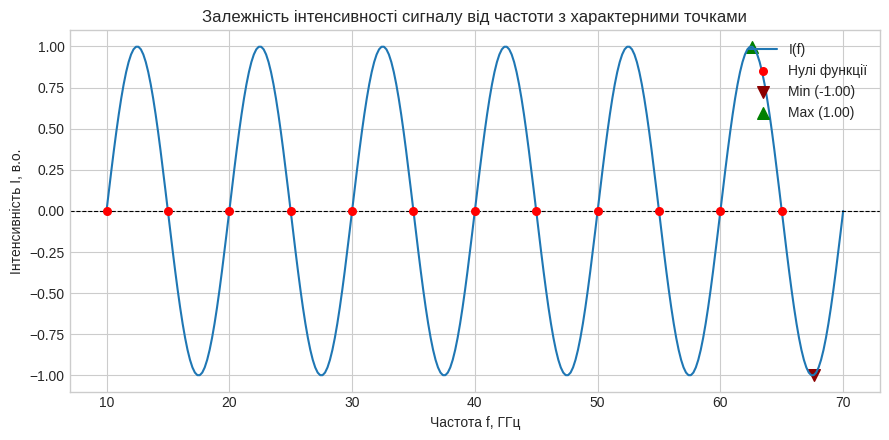

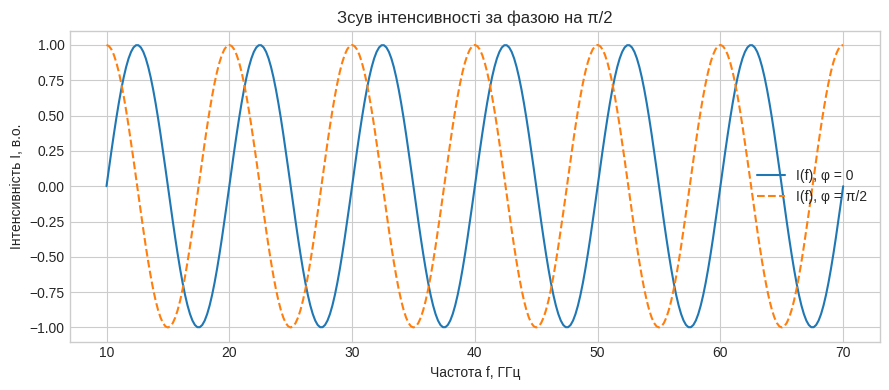

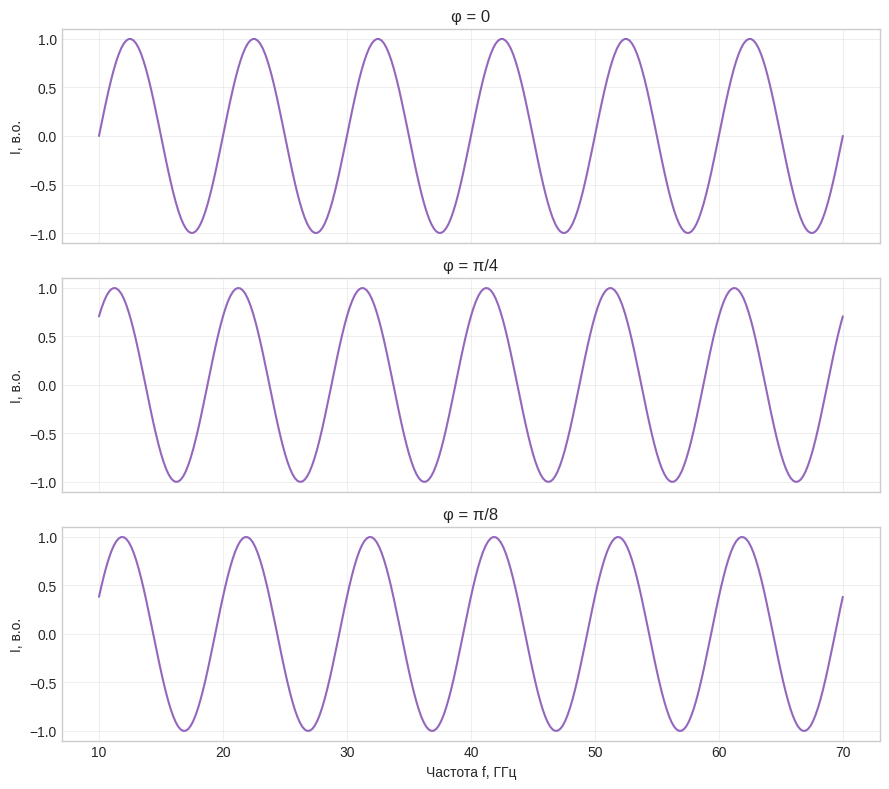

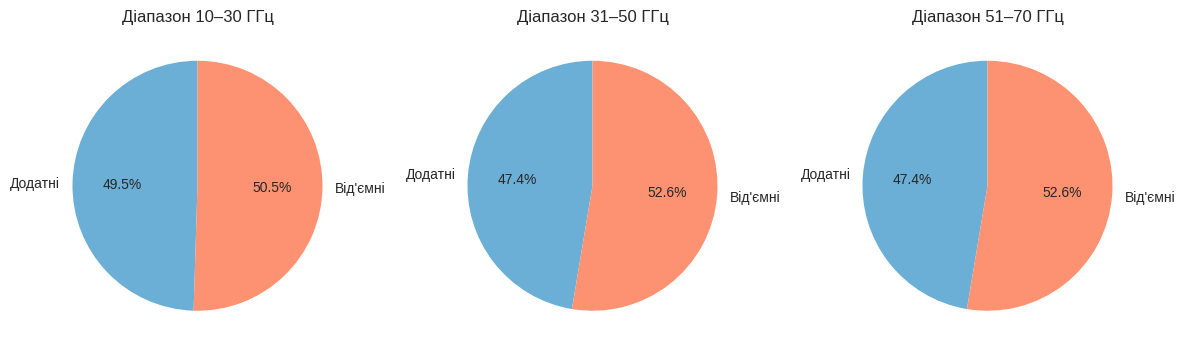

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Налаштування стилю
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (8, 4)

# 1. Генерація та запис у файл
f = np.arange(10, 70 + 0.2, 0.2)
tau = 0.1  # нс
phi = 0.0
I = np.sin(2 * np.pi * f * tau + phi)

np.savetxt(
    "signal.txt",
    np.column_stack([f, I]),
    fmt="%.4f",
    delimiter="\t",
    header="f_GHz\tI",
)

# а) та б) Графік залежності з екстремумами та нулями
# Пошук нулів через зміну знака з лінійною інтерполяцією
s = np.sign(I)
zero_idx = np.where(s[:-1] * s[1:] < 0)[0]
zeros_f = f[zero_idx] - I[zero_idx] * (f[zero_idx + 1] - f[zero_idx]) / (
    I[zero_idx + 1] - I[zero_idx]
)

# Пошук мінімумів та максимумів
min_val, max_val = np.min(I), np.max(I)
f_min, f_max = f[np.argmin(I)], f[np.argmax(I)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(f, I, label="I(f)", color="tab:blue", lw=1.5)
ax.axhline(0, color="black", lw=0.8, linestyle="--")

# Виділення точок
ax.scatter(zeros_f, np.zeros_like(zeros_f), color="red", s=30, label="Нулі функції", zorder=5)
ax.scatter([f_min], [min_val], color="darkred", marker="v", s=70, label=f"Min ({min_val:.2f})")
ax.scatter([f_max], [max_val], color="green", marker="^", s=70, label=f"Max ({max_val:.2f})")

ax.set_title("Залежність інтенсивності сигналу від частоти з характерними точками")
ax.set_xlabel("Частота f, ГГц")
ax.set_ylabel("Інтенсивність I, в.о.")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# в) Два графіки, зсунуті по фазі на pi/2
I_shift = np.sin(2 * np.pi * f * tau + np.pi / 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f, I, label="I(f), φ = 0", color="tab:blue")
ax.plot(f, I_shift, label="I(f), φ = π/2", color="tab:orange", linestyle="--")
ax.set_title("Зсув інтенсивності за фазою на π/2")
ax.set_xlabel("Частота f, ГГц")
ax.set_ylabel("Інтенсивність I, в.о.")
ax.legend()
plt.tight_layout()
plt.show()

# г) Три вікна: φ = 0, φ = π/4, φ = π/8
phases = [0, np.pi / 4, np.pi / 8]
titles = ["φ = 0", "φ = π/4", "φ = π/8"]

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax, p, t in zip(axes, phases, titles):
    ax.plot(f, np.sin(2 * np.pi * f * tau + p), color="tab:purple")
    ax.set_title(t)
    ax.set_ylabel("I, в.о.")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Частота f, ГГц")
plt.tight_layout()
plt.show()

# д) Кругові діаграми розподілу додатних/від'ємних значень
sub_bands = [(10, 30), (31, 50), (51, 70)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (low, high) in zip(axes, sub_bands):
    mask = (f >= low) & (f <= high)
    sub_I = I[mask]
    n_pos = np.sum(sub_I >= 0)
    n_neg = np.sum(sub_I < 0)
    ax.pie(
        [n_pos, n_neg],
        labels=["Додатні", "Від'ємні"],
        autopct="%.1f%%",
        colors=["#6baed6", "#fc9272"],
        startangle=90,
    )
    ax.set_title(f"Діапазон {low}–{high} ГГц")

plt.tight_layout()
plt.show()

Дані успішно завантажено! Точок: 17214, тип даних: float64


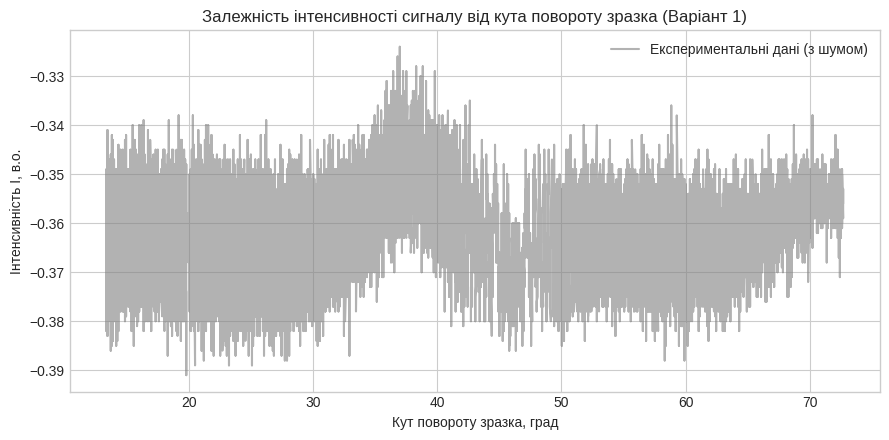

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import butter, filtfilt, find_peaks, medfilt, savgol_filter

# Налаштування вигляду графіків
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.figsize"] = (8, 4)

# ==============================================================================
# ПУНКТ 1: Завантаження даних з захистом від текстових заголовків і ком
# ==============================================================================
# Зчитуємо будь-яку кількість пробілів/табуляцій між колонками
try:
    df_var = pd.read_csv("Variant_1.txt", sep=r"\s+", header=None)
except Exception:
    df_var = pd.read_csv(
        "Variant_1.txt", sep=None, engine="python", header=None
    )

# Конвертуємо всі стовпчики у float (замінюючи кому на крапку, якщо число було текстом)
for col in df_var.columns:
    if df_var[col].dtype == object:
        df_var[col] = df_var[col].astype(str).str.replace(",", ".")
        df_var[col] = pd.to_numeric(df_var[col], errors="coerce")

# Видаляємо рядок із заголовком (який після to_numeric перетворився на NaN)
df_var = df_var.dropna().reset_index(drop=True)

# Згідно з інструкцією до роботи:
# 1 колонка - номер, 2 - енкодер, 3 - кут зразка (sample_angle), 4 - інтенсивність (I)
theta = df_var.iloc[:, 2].values.astype(float)
I_raw = df_var.iloc[:, 3].values.astype(float)

print(
    f"Дані успішно завантажено! Точок: {len(theta)}, тип даних: {I_raw.dtype}"
)

# Візуалізація сирих даних
plt.figure(figsize=(9, 4.5))
plt.plot(
    theta,
    I_raw,
    color="gray",
    alpha=0.6,
    label="Експериментальні дані (з шумом)",
)
plt.title("Залежність інтенсивності сигналу від кута повороту зразка (Варіант 1)")
plt.xlabel("Кут повороту зразка, град")
plt.ylabel("Інтенсивність I, в.о.")
plt.legend()
plt.tight_layout()
plt.show()

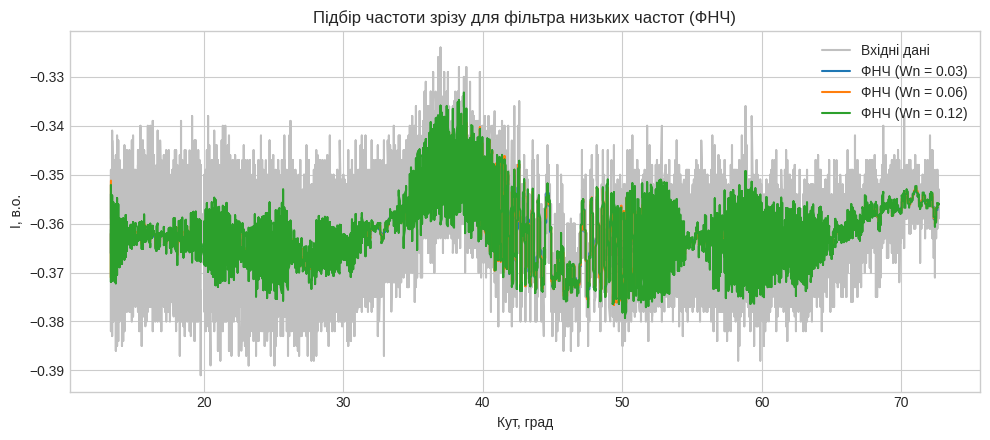

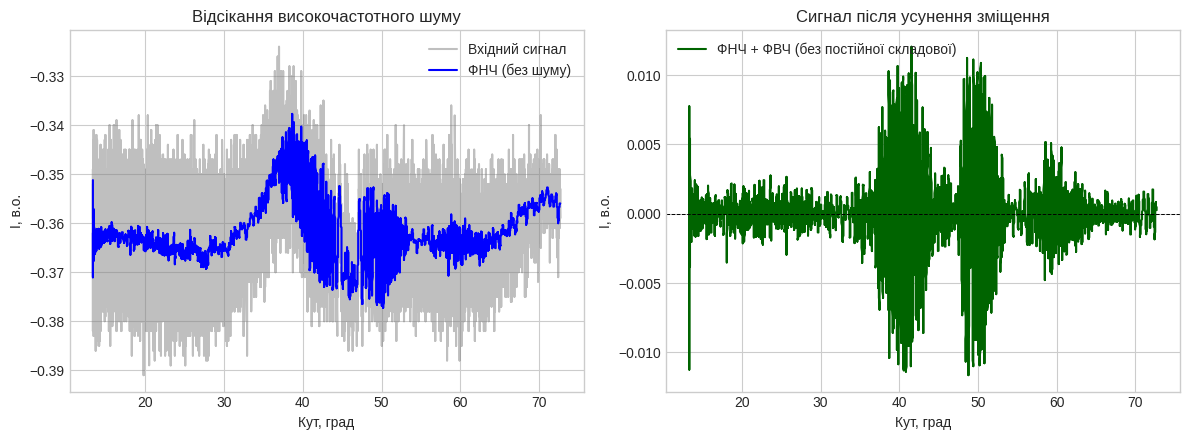

In [8]:
# ==============================================================================
# ПУНКТ 2: Фільтрація ФНЧ та ФВЧ Баттерворта (пошук оптимальної частоти зрізу)
# ==============================================================================
# 2.1. Демонстрація підбору частоти зрізу ФНЧ (щонайменше 3 значення Wn)
wn_list = [0.03, 0.06, 0.12]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(theta, I_raw, color="silver", label="Вхідні дані")

for wn in wn_list:
    b_low_test, a_low_test = butter(N=3, Wn=wn, btype="low")
    I_filt_test = filtfilt(b_low_test, a_low_test, I_raw)
    ax.plot(theta, I_filt_test, lw=1.5, label=f"ФНЧ (Wn = {wn})")

ax.set_title("Підбір частоти зрізу для фільтра низьких частот (ФНЧ)")
ax.set_xlabel("Кут, град")
ax.set_ylabel("I, в.о.")
ax.legend()
plt.tight_layout()
plt.show()

# 2.2. Робоча фільтрація:
# ФНЧ (Wn = 0.06) прибирає шум, ФВЧ (Wn = 0.015) прибирає постійне зміщення
b_low, a_low = butter(N=3, Wn=0.06, btype="low")
I_low = filtfilt(b_low, a_low, I_raw)

b_high, a_high = butter(N=3, Wn=0.015, btype="high")
I_clean = filtfilt(b_high, a_high, I_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(theta, I_raw, color="gray", alpha=0.5, label="Вхідний сигнал")
axes[0].plot(theta, I_low, color="blue", label="ФНЧ (без шуму)")
axes[0].set_title("Відсікання високочастотного шуму")
axes[0].set_xlabel("Кут, град")
axes[0].set_ylabel("I, в.о.")
axes[0].legend()

axes[1].plot(
    theta,
    I_clean,
    color="darkgreen",
    label="ФНЧ + ФВЧ (без постійної складової)",
)
axes[1].axhline(0, color="black", linestyle="--", lw=0.7)
axes[1].set_title("Сигнал після усунення зміщення")
axes[1].set_xlabel("Кут, град")
axes[1].set_ylabel("I, в.о.")
axes[1].legend()
plt.tight_layout()
plt.show()

RMSE апроксимації: 0.0027


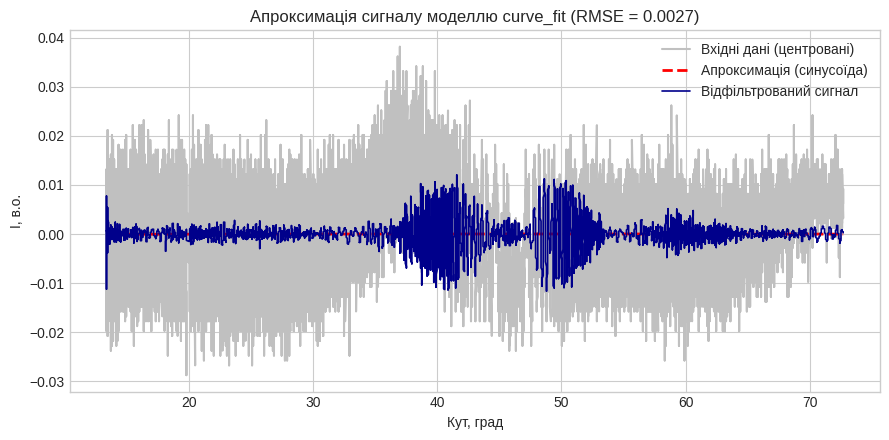

In [9]:
# ==============================================================================
# ПУНКТ 3: Апроксимація функції (curve_fit) та обчислення RMSE
# ==============================================================================
def harmonic_model(x, A, w, phi, c):
    return A * np.sin(w * x + phi) + c


# Початкове наближення параметрів (амплітуда, частота, фаза, зсув)
p0 = [
    (np.max(I_clean) - np.min(I_clean)) / 2,
    2 * np.pi / 90.0,
    0.0,
    np.mean(I_clean),
]
popt, _ = curve_fit(harmonic_model, theta, I_clean, p0=p0)
I_fit = harmonic_model(theta, *popt)

rmse = np.sqrt(np.mean((I_clean - I_fit) ** 2))
print(f"RMSE апроксимації: {rmse:.4f}")

plt.figure(figsize=(9, 4.5))
plt.plot(
    theta,
    I_raw - np.mean(I_raw),
    color="silver",
    label="Вхідні дані (центровані)",
)
plt.plot(
    theta,
    I_fit,
    color="red",
    linestyle="--",
    lw=2,
    label="Апроксимація (синусоїда)",
)
plt.plot(
    theta, I_clean, color="darkblue", lw=1.2, label="Відфільтрований сигнал"
)
plt.title(f"Апроксимація сигналу моделлю curve_fit (RMSE = {rmse:.4f})")
plt.xlabel("Кут, град")
plt.ylabel("I, в.о.")
plt.legend()
plt.tight_layout()
plt.show()

Кількість знайдених нулів: 754
Значення кутів для нулів (град): [13.32 13.32 13.32 13.32 13.32 13.32 13.41 13.41 13.41 13.41 13.41 13.41
 13.5  13.5  13.5  13.5  13.5  13.5  13.59 13.59 13.59 13.59 13.59 13.59
 13.68 13.68 13.68 13.68 13.76 13.76 13.85 13.94 13.94 14.03 14.03 14.12
 14.12 14.12 14.21 14.29 14.29 14.38 14.47 14.56 14.65 14.65 14.74 14.74
 14.82 14.86 14.91 15.   15.09 15.26 15.35 15.35 15.44 15.53 15.62 15.71
 15.79 15.88 15.88 15.88 16.06 16.15 16.24 16.32 16.5  16.59 16.68 16.85
 17.12 17.38 17.62 17.74 18.04 18.18 18.35 18.35 18.44 18.62 18.71 18.79
 18.88 19.06 19.06 19.15 19.15 19.24 19.25 19.32 19.41 19.5  19.5  19.5
 19.59 19.59 19.68 19.68 19.76 20.03 20.03 20.03 20.12 20.21 20.29 20.38
 20.38 20.47 20.56 20.56 20.65 20.74 20.74 20.74 20.82 20.82 20.91 20.91
 21.   21.   21.09 21.09 21.09 21.18 21.18 21.26 21.28 21.35 21.44 21.44
 21.53 21.6  21.62 21.71 21.71 21.79 21.88 21.88 21.97 22.06 22.15 22.24
 22.24 22.32 22.41 22.5  22.59 22.76 22.85 23.03 23.12 23.12 

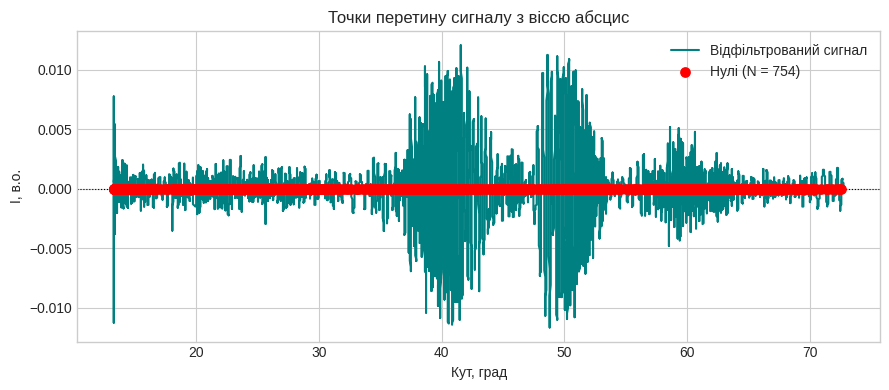

In [10]:
# ==============================================================================
# ПУНКТ 4: Кількість нулів функції (перетинів з віссю абсцис)
# ==============================================================================
s_clean = np.sign(I_clean)
idx_z = np.where(s_clean[:-1] * s_clean[1:] < 0)[0]
# Лінійна інтерполяція для визначення точного кута перетину
zeros_theta = theta[idx_z] - I_clean[idx_z] * (
    theta[idx_z + 1] - theta[idx_z]
) / (I_clean[idx_z + 1] - I_clean[idx_z])

print(f"Кількість знайдених нулів: {len(zeros_theta)}")
print("Значення кутів для нулів (град):", np.round(zeros_theta, 2))

plt.figure(figsize=(9, 4))
plt.plot(theta, I_clean, label="Відфільтрований сигнал", color="teal")
plt.axhline(0, color="black", lw=0.8, linestyle=":")
plt.scatter(
    zeros_theta,
    np.zeros_like(zeros_theta),
    color="red",
    s=45,
    zorder=5,
    label=f"Нулі (N = {len(zeros_theta)})",
)
plt.title("Точки перетину сигналу з віссю абсцис")
plt.xlabel("Кут, град")
plt.ylabel("I, в.о.")
plt.legend()
plt.tight_layout()
plt.show()

=== Таблиця екстремумів (extrema.csv) ===
     Тип  Кут_град  Інтенсивність
 Мінімум    16.588      -0.001572
Максимум    18.706       0.002180
 Мінімум    20.382      -0.001508
 Мінімум    22.676      -0.002186
Максимум    22.853       0.002413
Максимум    25.412       0.002012
 Мінімум    27.176      -0.001737
Максимум    28.941       0.001676
 Мінімум    32.824      -0.002005
Максимум    34.500       0.002611
 Мінімум    34.676      -0.001709
 Мінімум    35.294      -0.002850
Максимум    35.471       0.002045
Максимум    36.265       0.001886
 Мінімум    36.353      -0.002001
Максимум    36.706       0.001345
 Мінімум    37.059      -0.003694
 Мінімум    37.500      -0.006539
Максимум    37.588       0.003533
 Мінімум    37.941      -0.005930
Максимум    38.206       0.004266
 Мінімум    38.647      -0.005733
Максимум    38.735       0.007586
 Мінімум    39.176      -0.007411
Максимум    39.265       0.008897
Максимум    39.706       0.008174
 Мінімум    39.971      -0.007483
Максим

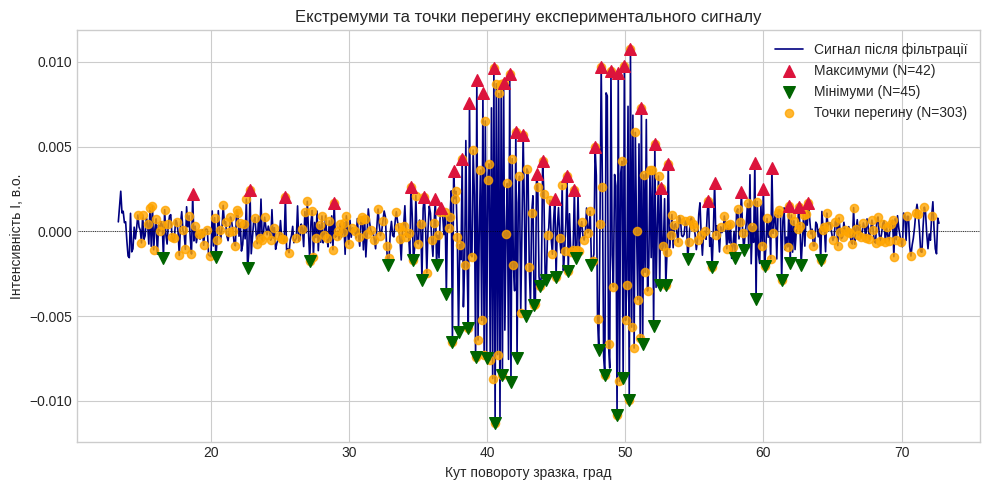

In [12]:
# ==============================================================================
# ПУНКТ 5 та 6 (ВИПРАВЛЕНИЙ): Екстремуми та точки перегину
# ==============================================================================

# 1. Захист від дублікатів кутів для усунення ділення на 0 в похідних
# Якщо в експерименті на один кут припадає кілька вимірів або є повтори:
df_unique = pd.DataFrame({'theta': theta, 'I_clean': I_clean}).drop_duplicates(subset=['theta']).sort_values('theta')
theta_u = df_unique['theta'].values
I_u = df_unique['I_clean'].values

# 2. Адаптивний підбір prominence (15% від повного розмаху сигналу)
signal_span = np.ptp(I_u)  # різниця між max та min
adaptive_prominence = signal_span * 0.15

# Пошук піків та западин
peaks, _ = find_peaks(I_u, prominence=adaptive_prominence, distance=5)
troughs, _ = find_peaks(-I_u, prominence=adaptive_prominence, distance=5)

# Якщо раптом піки все одно не знайдено (дуже плавний сигнал) — беремо глобальні
if len(peaks) == 0:
    peaks = np.array([np.argmax(I_u)])
if len(troughs) == 0:
    troughs = np.array([np.argmin(I_u)])

# Формуємо таблицю екстремумів
df_extrema = pd.DataFrame({
    'Тип': ['Максимум'] * len(peaks) + ['Мінімум'] * len(troughs),
    'Кут_град': np.concatenate([theta_u[peaks], theta_u[troughs]]),
    'Інтенсивність': np.concatenate([I_u[peaks], I_u[troughs]])
}).sort_values(by='Кут_град')

df_extrema.round(3).to_csv('extrema.csv', index=False)
print("=== Таблиця екстремумів (extrema.csv) ===")
print(df_extrema.to_string(index=False))

# 3. Точки перегину (на відсортованих унікальних кутах)
# Згладжуємо сигнал фільтром Савіцького-Голея
win_len = min(21, len(I_u) if len(I_u) % 2 != 0 else len(I_u) - 1)
I_sg = savgol_filter(I_u, window_length=max(5, win_len), polyorder=3)

# Обчислення першої та другої похідних без помилки divide by zero
d1 = np.gradient(I_sg, theta_u)
d2 = np.gradient(d1, theta_u)

# Пошук переходу другої похідної через нуль
s_d2 = np.sign(d2)
infl_idx = np.where(s_d2[:-1] * s_d2[1:] < 0)[0]
theta_infl = theta_u[infl_idx]
I_infl = I_u[infl_idx]

df_infl = pd.DataFrame({
    'Кут_град': theta_infl,
    'Інтенсивність': I_infl
}).sort_values(by='Кут_град')
df_infl.round(3).to_csv('inflection_points.csv', index=False)

print(f"\nЗнайдено точок перегину: {len(theta_infl)}")

# 4. Візуалізація результатів
plt.figure(figsize=(10, 5))
plt.plot(theta_u, I_u, color='navy', lw=1.2, label='Сигнал після фільтрації')
plt.scatter(theta_u[peaks], I_u[peaks], color='crimson', marker='^', s=70, zorder=5, label=f'Максимуми (N={len(peaks)})')
plt.scatter(theta_u[troughs], I_u[troughs], color='darkgreen', marker='v', s=70, zorder=5, label=f'Мінімуми (N={len(troughs)})')
if len(theta_infl) > 0:
    plt.scatter(theta_infl, I_infl, color='orange', marker='o', s=35, alpha=0.8, zorder=4, label=f'Точки перегину (N={len(theta_infl)})')

plt.axhline(0, color='black', lw=0.6, linestyle=':')
plt.title("Екстремуми та точки перегину експериментального сигналу")
plt.xlabel("Кут повороту зразка, град")
plt.ylabel("Інтенсивність I, в.о.")
plt.legend()
plt.tight_layout()
plt.show()

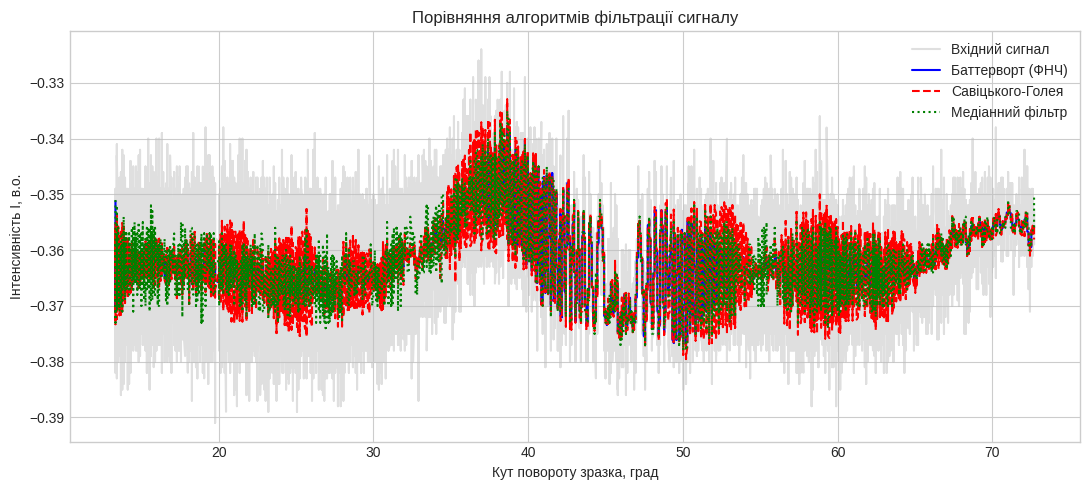

In [13]:
# ==============================================================================
# ПУНКТ 7: Порівняння з іншими фільтрами (Савіцького-Голея та медіанний)
# ==============================================================================
I_savgol = savgol_filter(I_raw, window_length=21, polyorder=3)
I_median = medfilt(I_raw, kernel_size=15)

plt.figure(figsize=(11, 5))
plt.plot(theta, I_raw, color="silver", alpha=0.5, label="Вхідний сигнал")
plt.plot(theta, I_low, color="blue", lw=1.5, label="Баттерворт (ФНЧ)")
plt.plot(
    theta,
    I_savgol,
    color="red",
    linestyle="--",
    lw=1.5,
    label="Савіцького-Голея",
)
plt.plot(
    theta,
    I_median,
    color="green",
    linestyle=":",
    lw=1.5,
    label="Медіанний фільтр",
)
plt.title("Порівняння алгоритмів фільтрації сигналу")
plt.xlabel("Кут повороту зразка, град")
plt.ylabel("Інтенсивність I, в.о.")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# ПУНКТ 8: Порівняння кількості піків до і після фільтрації
# ==============================================================================
raw_peaks, _ = find_peaks(I_raw, distance=1)
filt_peaks, _ = find_peaks(I_low, prominence=0.3, distance=10)

print(f"\nКількість максимумів на сирому сигналі: {len(raw_peaks)}")
print(f"Кількість максимумів після фільтрації: {len(filt_peaks)}")


Кількість максимумів на сирому сигналі: 5738
Кількість максимумів після фільтрації: 0
